# Tolerance Sweep Analysis\n\nEffect of `pos_tol` (position tolerance) and `ori_tol` (orientation tolerance) on grasp success.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("../multi_run_results_full.csv")
print(f"Loaded {len(df)} rows")
print(f"pos_tol values: {sorted(df['pos_tol'].unique())}")
print(f"ori_tol values: {sorted(df['ori_tol'].unique())}")
print(f"result values:  {df['result'].unique()}")
df.head()

Loaded 320 rows
pos_tol values: [np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08)]
ori_tol values: [np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.08)]
result values:  <StringArray>
['SUCCESS', 'MISSED', 'FAILED']
Length: 3, dtype: str


,timestamp,run,ball_x,ball_y,ball_z,pos_tol,ori_tol,vel_scale,accel_scale,settle_s,result
0,2026-05-07_02-51-10,1,0.35,0.0,0.065,0.01,0.01,0.5,0.5,1.0,SUCCESS
1,2026-05-07_02-51-10,2,0.30,0.1,0.065,0.01,0.01,0.5,0.5,1.0,SUCCESS
2,2026-05-07_02-51-10,3,0.30,-0.1,0.065,0.01,0.01,0.5,0.5,1.0,SUCCESS
3,2026-05-07_02-51-10,4,0.40,0.1,0.065,0.01,0.01,0.5,0.5,1.0,SUCCESS
4,2026-05-07_02-51-10,5,0.40,-0.1,0.065,0.01,0.01,0.5,0.5,1.0,SUCCESS


In [3]:
# Count successes per (pos_tol, ori_tol) pair
success_counts = (
    df[df["result"] == "SUCCESS"]
    .groupby(["pos_tol", "ori_tol"])
    .size()
    .reset_index(name="successes")
)

# Build full grid so missing combos show as 0
pos_vals = sorted(df["pos_tol"].unique())
ori_vals = sorted(df["ori_tol"].unique())
grid_index = pd.MultiIndex.from_product([pos_vals, ori_vals], names=["pos_tol", "ori_tol"])
success_counts = (
    success_counts
    .set_index(["pos_tol", "ori_tol"])
    .reindex(grid_index, fill_value=0)
    .reset_index()
)

# Total runs per combo (for reference)
total_counts = df.groupby(["pos_tol", "ori_tol"]).size().reset_index(name="total")
success_counts = success_counts.merge(total_counts, on=["pos_tol", "ori_tol"], how="left")
success_counts["success_rate"] = success_counts["successes"] / success_counts["total"]
success_counts.head(10)

,pos_tol,ori_tol,successes,total,success_rate
0,0.01,0.01,5,5,1.0
1,0.01,0.02,5,5,1.0
2,0.01,0.03,5,5,1.0
3,0.01,0.04,4,5,0.8
4,0.01,0.05,5,5,1.0
5,0.01,0.06,5,5,1.0
6,0.01,0.07,5,5,1.0
7,0.01,0.08,5,5,1.0
8,0.02,0.01,5,5,1.0
9,0.02,0.02,5,5,1.0


## 3-D Bar Chart — Number of Successes

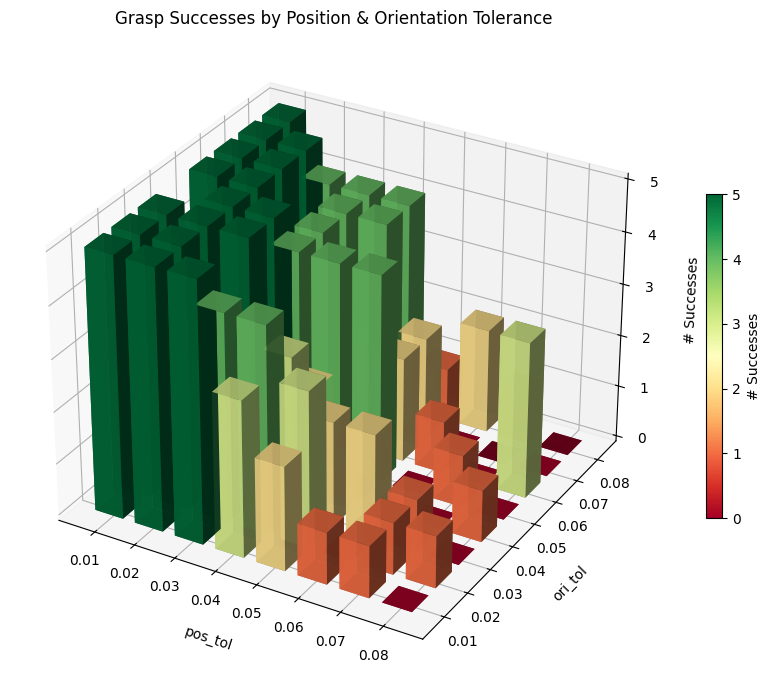

Saved successes_3d_bar.png


In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Bar positions
xpos = success_counts["pos_tol"].values
ypos = success_counts["ori_tol"].values
zpos = np.zeros(len(success_counts))
heights = success_counts["successes"].values

bar_width = 0.007
bar_depth = 0.007

# Color bars by height
norm = plt.Normalize(heights.min(), heights.max())
colors = plt.cm.RdYlGn(norm(heights))

ax.bar3d(xpos - bar_width / 2, ypos - bar_depth / 2, zpos,
         bar_width, bar_depth, heights,
         color=colors, shade=True, alpha=0.9)

ax.set_xlabel("pos_tol", labelpad=10)
ax.set_ylabel("ori_tol", labelpad=10)
ax.set_zlabel("# Successes", labelpad=10)
ax.set_title("Grasp Successes by Position & Orientation Tolerance")

ax.set_xticks(pos_vals)
ax.set_yticks(ori_vals)

sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5, label="# Successes")

plt.tight_layout()
plt.savefig("successes_3d_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved successes_3d_bar.png")

## 3-D Surface — Success Rate\n\nSame data normalized by total runs per combo, shown as a continuous surface.

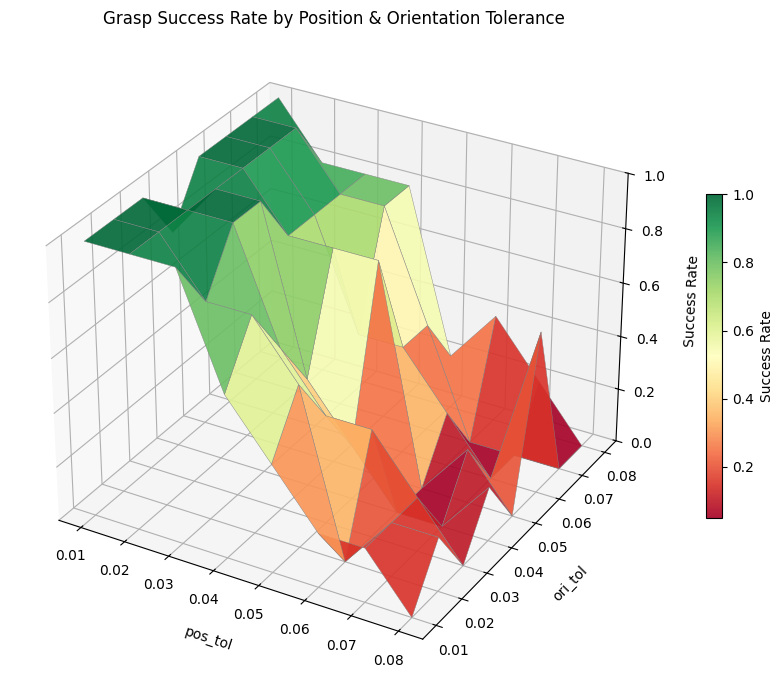

Saved success_rate_3d_surface.png


In [5]:
Z_counts = success_counts.pivot(index="ori_tol", columns="pos_tol", values="successes").values
Z_rate   = success_counts.pivot(index="ori_tol", columns="pos_tol", values="success_rate").values

X, Y = np.meshgrid(pos_vals, ori_vals)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z_rate, cmap="RdYlGn", edgecolor="grey",
                       linewidth=0.3, alpha=0.9)

ax.set_xlabel("pos_tol", labelpad=10)
ax.set_ylabel("ori_tol", labelpad=10)
ax.set_zlabel("Success Rate", labelpad=10)
ax.set_title("Grasp Success Rate by Position & Orientation Tolerance")
ax.set_zlim(0, 1)

fig.colorbar(surf, ax=ax, shrink=0.5, label="Success Rate")

plt.tight_layout()
plt.savefig("success_rate_3d_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved success_rate_3d_surface.png")